# Explainable AI: Pneumonia Detection with Grad-CAM

**Author:** Sevendi Eldrige Rifki Poluan

**Overview:** VGG19-based pneumonia detection with Grad-CAM explainability visualization.

**Prerequisites:** Complete [SETUP.md](./SETUP.md) before running this notebook.

In [1]:
# Note: Running on Mac M4 Pro - no NVIDIA GPU available
# For GPU acceleration on Mac, TensorFlow will use Metal Performance Shaders (MPS)
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print(f"Metal device found: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.16.2
Metal device found: True


## 1. Setup & Configuration

### Import Required Libraries

In [2]:
# Core libraries
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import itertools
from pathlib import Path

# Metrics and evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## 2. Dataset Preparation

#### Dataset Setup

The dataset should already be downloaded and extracted in the `chest_xray/` directory as per [SETUP.md](./SETUP.md#dataset-setup).

If not done yet, complete the setup instructions before proceeding with this notebook.

**For reference:** Dataset source is [Chest X-Ray Pneumonia on Kaggle](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)

In [3]:
# Dataset download (already completed in SETUP.md)
# !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

In [4]:
# Dataset extraction (already completed in SETUP.md)
# !unzip chest-xray-pneumonia.zip

In [5]:
# Verify dataset structure (should show NORMAL and PNEUMONIA directories)
# !ls chest_xray/train

In [6]:
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]

# Compute class weights from training folder counts to reduce class imbalance bias
train_normal_count = sum(1 for p in Path("chest_xray/train/NORMAL").iterdir() if p.is_file())
train_pneumonia_count = sum(1 for p in Path("chest_xray/train/PNEUMONIA").iterdir() if p.is_file())
total_train = train_normal_count + train_pneumonia_count

class_weight = {
    0: total_train / (2.0 * train_normal_count),
    1: total_train / (2.0 * train_pneumonia_count),
}

print("Train class counts:", {"NORMAL": train_normal_count, "PNEUMONIA": train_pneumonia_count})
print("Class weights:", class_weight)

Train class counts: {'NORMAL': 1341, 'PNEUMONIA': 3875}
Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


In [7]:
# Load datasets from separate directories (prevents data leakage)
# Train set: for model training
train_ds = tf.keras.utils.image_dataset_from_directory(
    "chest_xray/train",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    image_size=(224, 224),
    shuffle=True,
    seed=42,
    batch_size=None,
)

# Test set: for final evaluation (no shuffle for stable metrics)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "chest_xray/test",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    image_size=(224, 224),
    shuffle=False,
    batch_size=None,
)

# Validation set: for early stopping and model selection during training (no shuffle)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "chest_xray/val",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    image_size=(224, 224),
    shuffle=False,
    batch_size=None,
)

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Found 16 files belonging to 2 classes.


2026-05-29 06:38:22.986203: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-05-29 06:38:22.986225: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-05-29 06:38:22.986228: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.72 GB
2026-05-29 06:38:22.986244: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-29 06:38:22.986255: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### Visualize Sample Training Data

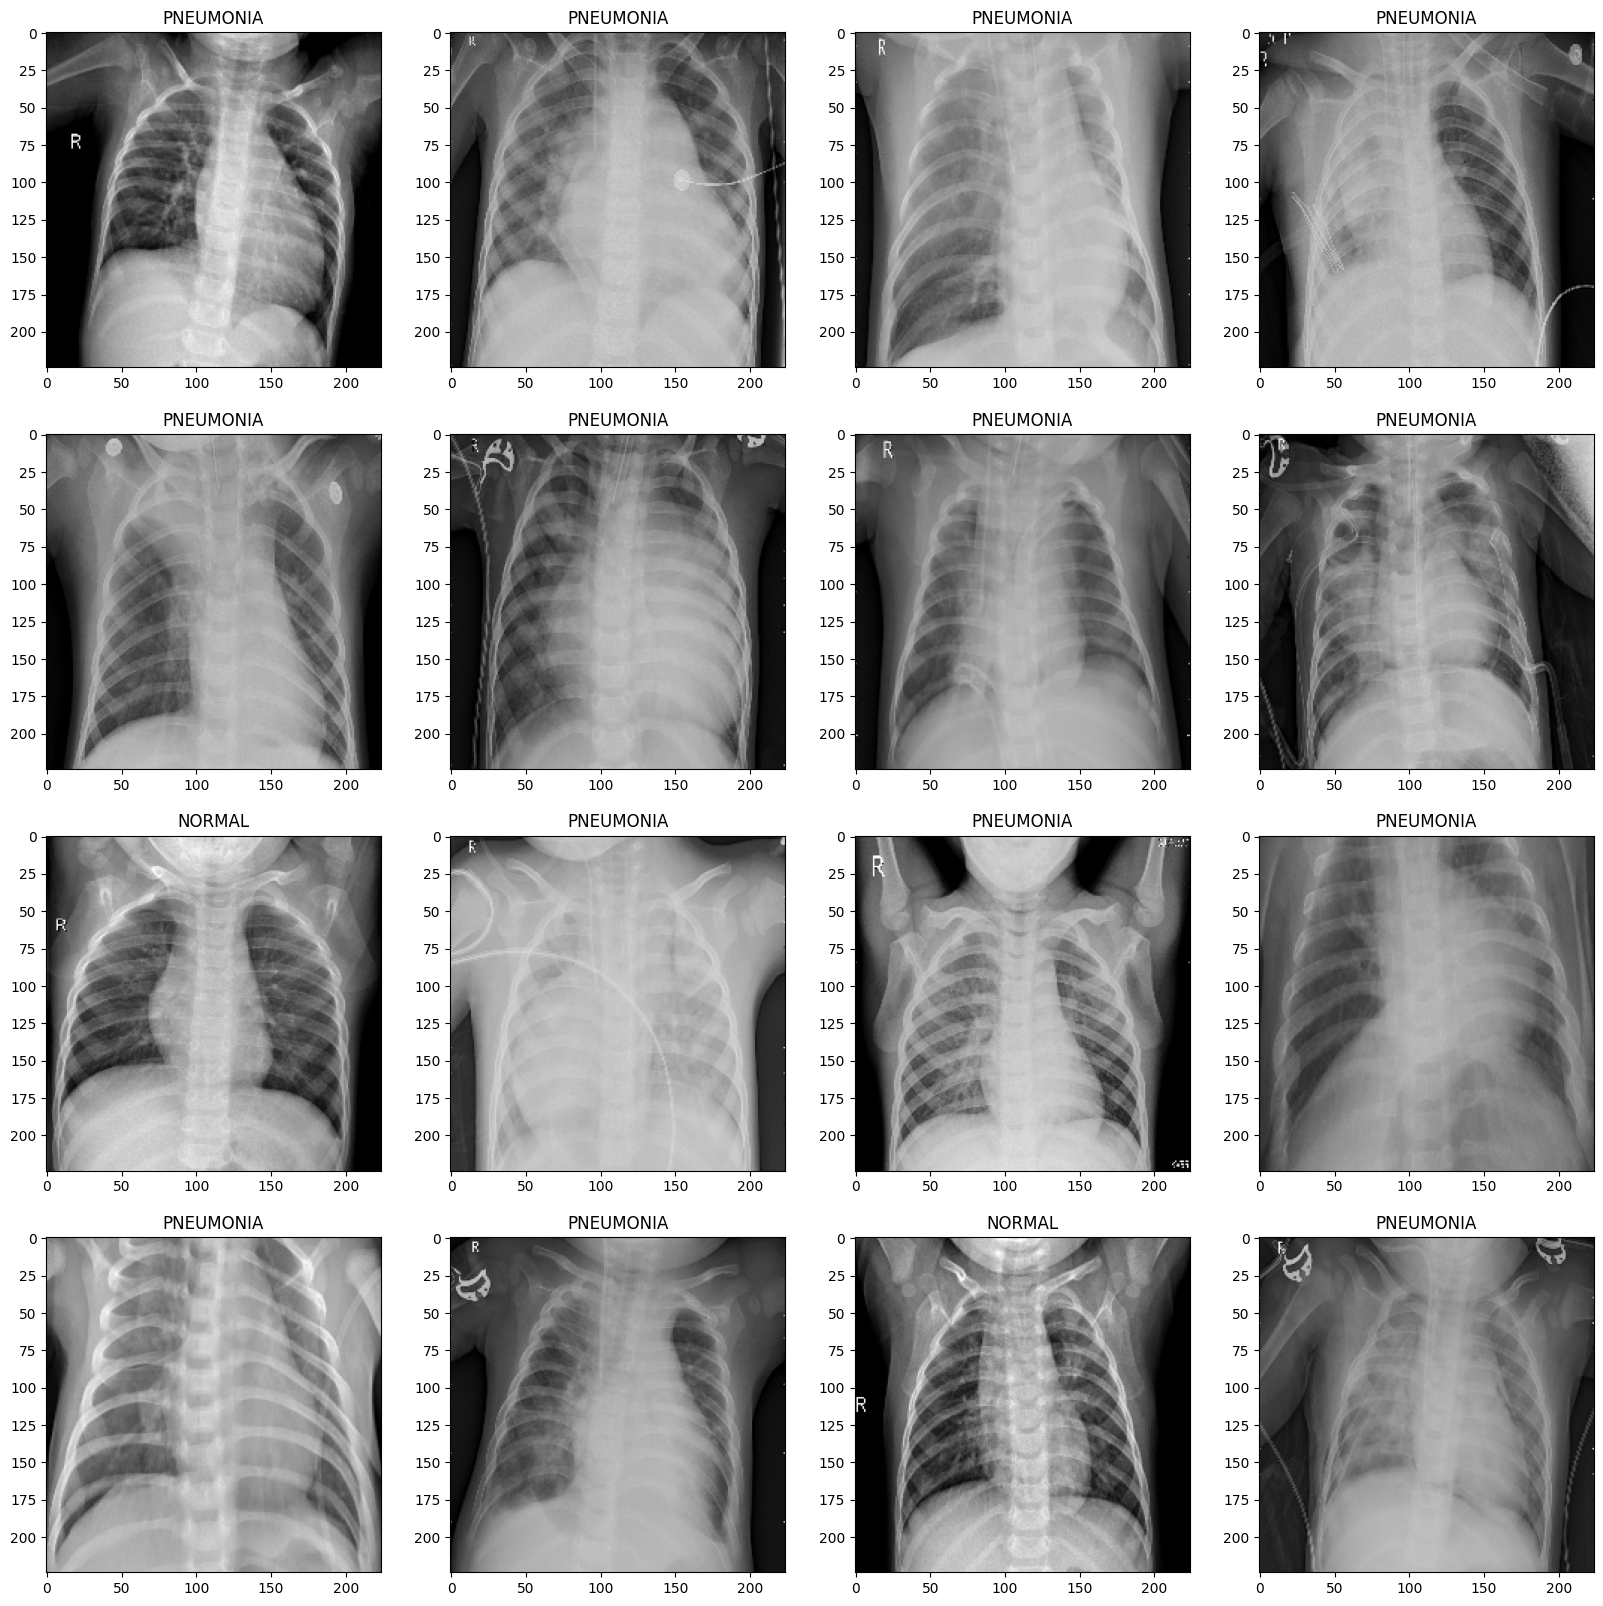

In [8]:
row, col = 4, 4
fig, axes = plt.subplots(row, col, figsize=(20, 20))

for index, x in enumerate(train_ds):
    axes[index // row, index % col].imshow(x[0].numpy().astype(int))
    axes[index // row, index % col].set_title(CLASS_NAMES[x[1].numpy().argmax()])
    
    if index == (row * col) - 1:
        break
        
plt.show()
    

### Prepare Datasets for Training

Resize images to 256x256 and create batched datasets with caching and prefetching for efficient training.

In [9]:
# Define batch size and image dimensions
BATCH_SIZE = 32
IMG_SIZE = [256, 256]

# Light augmentation to improve generalization
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

# Preprocess for training: resize, augment, and apply VGG19 preprocessing
def preprocess_train(image, label):
    image = tf.cast(tf.image.resize(image, IMG_SIZE), tf.float32)
    image = data_augmentation(image, training=True)
    image = tf.keras.applications.vgg19.preprocess_input(image)
    return image, label

# Preprocess for validation/test: resize and apply VGG19 preprocessing
def preprocess_eval(image, label):
    image = tf.cast(tf.image.resize(image, IMG_SIZE), tf.float32)
    image = tf.keras.applications.vgg19.preprocess_input(image)
    return image, label

# Build performant tf.data pipelines
train = train_ds.map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test = test_ds.map(preprocess_eval, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

# The built-in val/ folder only has 16 images — too small for stable monitoring.
# Use the test set (624 images) as validation during training for reliable callbacks.
val = test

## 3. Model Development

### Build VGG19 Transfer Learning Model

In [10]:
def create_model(unfreeze_from_block=None, learning_rate=3e-4):
    # Use VGG19 pre-trained on ImageNet for transfer learning
    base_model = tf.keras.applications.VGG19(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + [3],
    )
    base_model._name = "vgg19_base"

    # Stage control: freeze all first, then optionally unfreeze top blocks for fine-tuning
    base_model.trainable = False
    if unfreeze_from_block is not None:
        base_model.trainable = True
        unfreeze = False
        for layer in base_model.layers:
            if layer.name == unfreeze_from_block:
                unfreeze = True
            layer.trainable = unfreeze

    # Classification head with regularization
    x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
    x = tf.keras.layers.Dropout(0.4)(x)
    x = tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
    )(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax")(x)

    model = tf.keras.Model(base_model.input, outputs)
    model.compile(
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    return model

In [11]:
# Stage 1 model: train classification head only
model = create_model(unfreeze_from_block=None, learning_rate=3e-4)

In [12]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,090,306 (76.64 MB)

 Trainable params: 65,922 (257.51 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

### Configure Training Callbacks

Define custom checkpoint saving and early stopping callbacks.

In [13]:
class ModelCheckpointCustom(tf.keras.callbacks.Callback):
    
    def __init__(self, model_path, save_best_only=False):
        super(ModelCheckpointCustom, self).__init__()
         
        self.model_path = model_path
        self.save_best_only = save_best_only
        self.best_val_loss = float('inf') 

    def on_epoch_end(self, epoch, logs=None): 
        _ = epoch  # Keep callback signature explicit and lint-clean.
        if logs is None:
            return
        
        current_val_loss = logs.get('val_loss', float('inf'))
         
        if self.save_best_only and current_val_loss < self.best_val_loss: 
            self.best_val_loss = current_val_loss 
            self.model.save_weights(self.model_path) 
        elif not self.save_best_only:
            self.model.save_weights(self.model_path)  

save_callbacks = ModelCheckpointCustom(model_path='saved_weights/model.weights.h5', save_best_only=True)

In [14]:
# Monitor validation loss for better generalization
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

# Reduce LR when validation loss plateaus
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1,
)

### Train the Model

Two-stage training:
1. Train classification head with frozen VGG19 base
2. Fine-tune upper VGG19 block with lower learning rate

Class weighting and learning-rate reduction are enabled to improve generalization.
GPU acceleration (Metal) will be used on Mac automatically.

In [ ]:
# Two-stage training for better generalization
EPOCHS_HEAD = 7
EPOCHS_FINETUNE = 14

# Stage 1: train only the new classification head
history_head = model.fit(
    train,
    epochs=EPOCHS_HEAD,
    validation_data=val,
    class_weight=class_weight,
    callbacks=[early_stopping, reduce_lr, save_callbacks],
)

# Stage 2: unfreeze top VGG block and continue with lower LR
# Note: In this model definition, VGG layers are flattened into model.layers
# (no nested "vgg19_base" layer object is present).
unfreeze = False
for layer in model.layers:
    if layer.name == "block5_conv1":
        unfreeze = True
    if layer.name.startswith("block"):
        layer.trainable = unfreeze

# clipnorm=1.0 prevents gradient explosion when fine-tuning deep VGG layers
model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, clipnorm=1.0),
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

# Fresh callbacks for Stage 2 — prevents stale EarlyStopping/ReduceLROnPlateau
# state from Stage 1 causing a premature stop or missed LR reduction
early_stopping_ft = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)
reduce_lr_ft = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1,
)
save_callbacks_ft = ModelCheckpointCustom(
    model_path="saved_weights/model.weights.h5",
    save_best_only=True,
)

history_finetune = model.fit(
    train,
    epochs=EPOCHS_HEAD + EPOCHS_FINETUNE,
    initial_epoch=EPOCHS_HEAD,
    validation_data=val,
    class_weight=class_weight,
    callbacks=[early_stopping_ft, reduce_lr_ft, save_callbacks_ft],
)

# Merge histories for plotting
history_dict = {
    "loss": history_head.history.get("loss", []) + history_finetune.history.get("loss", []),
    "accuracy": history_head.history.get("accuracy", []) + history_finetune.history.get("accuracy", []),
    "auc": history_head.history.get("auc", []) + history_finetune.history.get("auc", []),
    "val_loss": history_head.history.get("val_loss", []) + history_finetune.history.get("val_loss", []),
    "val_accuracy": history_head.history.get("val_accuracy", []) + history_finetune.history.get("val_accuracy", []),
    "val_auc": history_head.history.get("val_auc", []) + history_finetune.history.get("val_auc", []),
}

Epoch 1/7


2026-05-29 06:38:24.352009: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


163/163 ━━━━━━━━━━━━━━━━━━━━ 39s 232ms/step - accuracy: 0.7331 - auc: 0.7883 - loss: 1.8908 - val_accuracy: 0.8654 - val_auc: 0.9165 - val_loss: 0.9067 - learning_rate: 3.0000e-04
Epoch 2/7
163/163 ━━━━━━━━━━━━━━━━━━━━ 38s 229ms/step - accuracy: 0.8215 - auc: 0.8802 - loss: 1.3134 - val_accuracy: 0.8702 - val_auc: 0.9284 - val_loss: 0.8063 - learning_rate: 3.0000e-04
Epoch 3/7
146/163 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.8373 - auc: 0.8919 - loss: 1.2125

### Plot Training History

Visualize training and validation loss/accuracy across epochs.

In [ ]:
pd.DataFrame(history_dict).plot(figsize=(10, 5), title="Training Curves (Head + Fine-tuning)")
plt.grid(alpha=0.3)
plt.show()

## 4. Model Evaluation

### Load Trained Model and Evaluate

In [ ]:
loaded_model = create_model()

In [ ]:
loaded_model.load_weights("saved_weights/model.weights.h5")

In [ ]:
y_pred = loaded_model.evaluate(test)

In [ ]:
eval_results = loaded_model.evaluate(test, verbose=0, return_dict=True)

if isinstance(eval_results, dict):
	print("Testing accuracy:", eval_results.get("accuracy"))
elif isinstance(eval_results, (list, tuple)) and len(eval_results) > 1:
	print("Testing accuracy:", eval_results[1])
else:
	print("Testing accuracy:", eval_results)

## 5. Explainability with Grad-CAM

### Implement Grad-CAM Class

Grad-CAM (Gradient-weighted Class Activation Mapping) visualizes which image regions contribute most to predictions.

In [ ]:
class GradCAM(object):

    def __init__(self, model, beta=0.18, activation_percentile=95, mask_smooth_sigma=1.5):
        self.model = model
        self.beta = beta
        self.activation_percentile = activation_percentile
        self.mask_smooth_sigma = mask_smooth_sigma

    def _to_grayscale_base(self, image):
        img = np.asarray(image).astype(np.float32)

        # Normalize unknown ranges safely to [0, 255]
        img_min, img_max = float(np.min(img)), float(np.max(img))
        if img_max <= 1.5:
            img = img * 255.0
        elif img_min < 0.0 or img_max > 255.0:
            img = (img - img_min) / (img_max - img_min + 1e-8)
            img = img * 255.0

        # Build pure grayscale base so no channel tint can appear
        if img.ndim == 2:
            gray = img
        else:
            gray = np.mean(img[..., :3], axis=-1)

        gray = np.clip(gray, 0.0, 255.0)
        base = np.stack([gray, gray, gray], axis=-1)
        return base.astype(np.float32)

    def apply_heatmap(self, heatmap, image):
        base = self._to_grayscale_base(image)
        h, w = base.shape[:2]
        heatmap = cv2.resize(heatmap, (w, h), interpolation=cv2.INTER_LINEAR)

        # Keep only top activations -> no full-image background tint
        threshold = float(np.percentile(heatmap, self.activation_percentile))
        activation = np.clip((heatmap - threshold) / (1.0 - threshold + 1e-8), 0.0, 1.0).astype(np.float32)
        activation = cv2.GaussianBlur(activation, (0, 0), self.mask_smooth_sigma)

        # Red overlay in RGB so hotspots are clearly red (not blue/cyan)
        heat_color = np.zeros_like(base, dtype=np.float32)
        heat_color[..., 0] = 255.0  # R

        # Blend only where activation exists
        mix = np.clip(self.beta * activation[..., None], 0.0, 1.0)
        out = base * (1.0 - mix) + heat_color * mix

        return np.clip(out, 0, 255).astype(np.uint8)

    def gradCAM(self, x_test=None, name="block5_conv3", index_class=0):
        if x_test is None:
            raise ValueError("x_test must not be None")

        raw_image = x_test.numpy() if tf.is_tensor(x_test) else np.asarray(x_test)

        with tf.GradientTape() as tape:
            last_conv_layer = self.model.get_layer(name)
            grad_model = tf.keras.Model(
                [self.model.input],
                [self.model.output, last_conv_layer.output],
            )

            input_tensor = tf.expand_dims(tf.cast(raw_image, tf.float32), axis=0)
            input_tensor = tf.keras.applications.vgg19.preprocess_input(input_tensor)

            predictions, conv_output = grad_model(input_tensor)
            class_score = tf.math.log(predictions[:, index_class] + 1e-8)
            grads = tape.gradient(class_score, conv_output)
            pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        conv_output = conv_output[0]
        heatmap = tf.reduce_sum(conv_output * pooled_grads, axis=-1)
        heatmap = tf.maximum(heatmap, 0)
        heatmap = heatmap.numpy()

        if float(np.max(heatmap)) <= 1e-8:
            return self._to_grayscale_base(raw_image).astype(np.uint8)

        p99 = float(np.percentile(heatmap, 99))
        if p99 > 1e-8:
            heatmap = np.clip(heatmap / p99, 0.0, 1.0)
        else:
            heatmap = heatmap / (float(np.max(heatmap)) + 1e-8)

        return self.apply_heatmap(heatmap, raw_image)

In [ ]:
gradCam = GradCAM(loaded_model, beta=0.18, activation_percentile=95, mask_smooth_sigma=1.5)

In [ ]:
# Collect predictions from test set to balance NORMAL and PNEUMONIA
test_images = []
test_labels = []
test_predictions = []
test_pneumonia_probs = []

for x, y in test_ds:
    x_test = tf.image.resize(x, IMG_SIZE)
    model_input = tf.expand_dims(tf.cast(x_test, tf.float32), axis=0)
    model_input = tf.keras.applications.vgg19.preprocess_input(model_input)

    pred_probs = loaded_model.predict(model_input, verbose=0)[0]
    y_pred = int(np.argmax(pred_probs))
    pneu_prob = float(pred_probs[1])
    y_true = int(np.argmax(y.numpy()))

    test_images.append(x_test.numpy())
    test_labels.append(y_true)
    test_predictions.append(y_pred)
    test_pneumonia_probs.append(pneu_prob)

# Categorize predictions: correct vs incorrect for each class
correct_normal = [i for i in range(len(test_predictions)) if test_predictions[i] == 0 and test_labels[i] == 0]
correct_pneumonia = [i for i in range(len(test_predictions)) if test_predictions[i] == 1 and test_labels[i] == 1]
incorrect_normal = [i for i in range(len(test_predictions)) if test_predictions[i] == 0 and test_labels[i] == 1]
incorrect_pneumonia = [i for i in range(len(test_predictions)) if test_predictions[i] == 1 and test_labels[i] == 0]

print(f"Correct NORMAL: {len(correct_normal)}")
print(f"Correct PNEUMONIA: {len(correct_pneumonia)}")
print(f"Incorrect (missed PNEUMONIA): {len(incorrect_normal)}")
print(f"Incorrect (false PNEUMONIA): {len(incorrect_pneumonia)}")

# Plot more images for richer comparison
MAX_PLOTS = 64  # Increase this if needed
available = len(test_predictions)
target_total = min(MAX_PLOTS, available)

groups = [correct_normal, correct_pneumonia, incorrect_pneumonia, incorrect_normal]
per_group = max(1, target_total // 4)
sampled_indices = []

# Balanced selection from each group first
for group in groups:
    sampled_indices.extend(group[:per_group])

# Fill remaining slots using samples closest to decision boundary
if len(sampled_indices) < target_total:
    selected = set(sampled_indices)
    candidate_indices = sorted(
        range(available),
        key=lambda i: abs(test_pneumonia_probs[i] - 0.5),
    )
    for i in candidate_indices:
        if i not in selected:
            sampled_indices.append(i)
            selected.add(i)
        if len(sampled_indices) >= target_total:
            break

sampled_indices = sampled_indices[:target_total]

# Build dynamic grid size
row = int(np.ceil(np.sqrt(target_total)))
col = int(np.ceil(target_total / row))

fig, axes = plt.subplots(row, col, figsize=(col * 3, row * 3))
axes = np.array(axes).reshape(-1)

for plot_idx, img_idx in enumerate(sampled_indices):
    x_test_img = test_images[img_idx]
    y_true = test_labels[img_idx]
    y_pred = test_predictions[img_idx]
    pneu_prob = test_pneumonia_probs[img_idx]
    pred_conf = max(pneu_prob, 1.0 - pneu_prob)

    is_correct = y_pred == y_true
    status = "✓" if is_correct else "✗"

    # Compute Grad-CAM for predicted class
    display_img = gradCam.gradCAM(x_test_img, name="block5_conv3", index_class=y_pred)

    axes[plot_idx].imshow(display_img)
    axes[plot_idx].set_title(
        f"{status} Pred:{CLASS_NAMES[y_pred]} True:{CLASS_NAMES[y_true]}\n"
        f"P(PNEUM)={pneu_prob:.3f} Conf={pred_conf:.3f}",
        fontsize=7,
        color="green" if is_correct else "red",
    )
    axes[plot_idx].axis("off")

# Hide unused subplots
for idx in range(len(sampled_indices), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig("Sample results/sample_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → Sample results/sample_results.png")

### Compute Performance Metrics

Calculate accuracy, precision, recall, F1-score, and confusion matrix on the test set.

In [ ]:
def conf_matrix(y_test=None, y_pred=None, class_names=None):
    
    if y_test is None or y_pred is None:
        raise ValueError("y_test and y_pred must not be None")
    cm = confusion_matrix(np.asarray(y_test), np.asarray(y_pred))
    
    fig, ax = plt.subplots(figsize=(8, 8))
    a = ax.matshow(cm, cmap="Greens")
    
    fig.colorbar(a)  
    
    if class_names is None:
        class_names = [str(i) for i in range(cm.shape[0])]
    elif len(class_names) != cm.shape[0]:
        raise ValueError("class_names length must match confusion matrix dimensions")

    ax.set(
        title="Confusion Matrix",
        xlabel="Predicted label",
        ylabel="Actual label",
        xticks=np.arange(cm.shape[1]),
        yticks=np.arange(cm.shape[0]),
        xticklabels=class_names,
        yticklabels=class_names
    )
    
    ax.xaxis.set_label_position("bottom")
    ax.xaxis.tick_bottom()
    
    plt.xticks(rotation=60, fontsize=20)
    plt.yticks(fontsize=20)

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f"{cm[i, j]}",
                  horizontalalignment="center", color="black" if cm[i, j] < (cm.max() + cm.min()) / 2 else "white",
                  fontsize=12)

In [ ]:
y_pred = []
y_truth = []

for x, y in test:
    probs = loaded_model.predict(x, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1))
    y_truth.extend(np.argmax(y.numpy(), axis=1))

y_true = np.array(y_truth)
y_prediction = np.array(y_pred)

In [ ]:
# Compute comprehensive evaluation metrics on test set
accuracy = accuracy_score(y_true, y_prediction)
precision = precision_score(y_true, y_prediction, average='macro', zero_division=0)
recall = recall_score(y_true, y_prediction, average='macro', zero_division=0)
f1 = f1_score(y_true, y_prediction, average='macro', zero_division=0)
confusion_mat = confusion_matrix(y_true, y_prediction)

# Print results
print("=" * 50)
print("MODEL EVALUATION METRICS (TEST SET)")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nConfusion Matrix:")
print(pd.DataFrame(
    confusion_mat,
    index=[f"True {cls}" for cls in CLASS_NAMES],
    columns=[f"Pred {cls}" for cls in CLASS_NAMES],
))
print("=" * 50)

In [ ]:
conf_matrix(y_test=y_true, y_pred=y_prediction, class_names=CLASS_NAMES)
plt.savefig("Sample results/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → Sample results/confusion_matrix.png")

## 6. Notes and Limitations

This notebook is built for **experimental and educational purposes**.

The current model and Grad-CAM visualization are useful for exploration, but they are **not** intended for direct clinical decision-making without further validation.

### What can be improved next

1. Use larger and more diverse datasets (different hospitals, devices, populations).
2. Add stronger validation protocols (cross-validation and external test sets).
3. Improve calibration and decision thresholds for better clinical interpretability.
4. Compare multiple architectures (e.g., EfficientNet, DenseNet, ViT-based models).
5. Add reliability checks and uncertainty estimation.
6. Review Grad-CAM outputs with domain experts (radiologists) to confirm clinical relevance.

With additional data, tuning, and validation, this pipeline can be improved significantly for more robust performance.